# BBM409 Assignment 3: Anomaly Detection in Machinery Sounds

**Student:** Ufuk Tanrıverdi  
**ID:** 2230356136  
**Course:** BBM409 Introduction to Machine Learning Lab, Spring 2026

## Problem

We are given the DCASE 2020 Challenge Task 2 development dataset, which contains recordings of six machine types: ToyCar, ToyConveyor, fan, pump, slider, and valve. The task is to decide, for a given test recording, whether the machine sounds normal or anomalous.

The setup has a twist we should consider though: **the training set contains only normal sounds**. No anomalous examples are available during training. This means we cannot treat the problem as standard binary classification. Instead, we need an approach that learns what "normal" looks like and flags anything that deviates.

## Approach

I'll use **autoencoders**. An autoencoder is a neural network trained to reconstruct its own input: it compresses the input into a low-dimensional bottleneck representation and then expands it back to the original shape. It is the go to approach for anomaly detection tasks. When trained only on normal data, the network learns compact patterns that describe normal sounds well. At test time:

- Normal sounds reconstruct accurately (low reconstruction error)
- Anomalous sounds reconstruct poorly (high reconstruction error) because the network has never learned their patterns

We use the reconstruction error as an **anomaly score** and threshold it to classify a sound as normal or anomalous. Evaluation is done with ROC-AUC, which avoids the need to pick a threshold up front.

## Four architectures

1. Single-layer neural network: input → bottleneck → output
2. MLP with two hidden layers: input → hidden → bottleneck → hidden → output
3. CNN with one convolutional layer and one fully connected layer
4. CNN with two convolutional layers and two fully connected layers

The MLP variants are implemented from scratch in NumPy.
The CNN variants use PyTorch, which the assignment explicitly permits for the CNN section.

## Feature representations

Raw audio cannot be fed directly to an autoencoder. We compare three time-frequency representations:

- **Mel spectrogram**: the DCASE baseline's choice, mel-scale frequency bins
- **STFT spectrogram**: linear-frequency short-time Fourier transform
- **Wavelet scalogram**: continuous wavelet transform, trades frequency resolution for time resolution at high frequencies

## Scope

To keep the experiment count manageable, I'll develop and evaluate on **ToyCar**, which has the largest training set (4000 clips) and a balanced test set (1400 normal, 1059 anomalous).  

I could've selected all the machine types, but that would have been too time-consuming given the number of architectures and features I'm testing. Focusing on one machine type allows me to do a deeper analysis of the results.

## Environment

- Python 3.12, dependencies managed with `uv`
- PyTorch 2.11 with CUDA 12.8 for the CNN section
- Training runs on a server GPU (specifcally NVIDIA RTX 5000 Ada, 32GB)
- All random seeds fixed for reproducibility

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # before importing torch
# this is only for the machine I am using, this cell can be skipped on other machines with a single GPU
# it is important to set this before importing torch, otherwise torch will see all the GPUs and may not use the one I want

In [2]:
import sys
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

# Project code lives in a sibling ./code directory
sys.path.insert(0, os.path.abspath("code"))

from config import SEED
# Setting the seed value once and for all for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Python       : {sys.version.split()[0]}")
print(f"NumPy        : {np.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"CUDA avail.  : {torch.cuda.is_available()}")
print(f"Device       : {device}")
if torch.cuda.is_available():
    print(f"GPU name     : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Python       : 3.12.2
NumPy        : 2.4.4
PyTorch      : 2.11.0+cu128
CUDA avail.  : True
Device       : cuda
GPU name     : NVIDIA RTX 5000 Ada Generation
GPU memory   : 33.8 GB


## Dataset overview

This dataset splits each machine type into a `train/` directory (normal clips only) and a `test/` directory (normal + anomalous clips, labeled by filename prefix). Files are named:  
`normal_id_00_00000005.wav`  
`anomaly_id_00_00000005.wav`  

The `id_XX` part refers to a specific individual machine of that type. For example, the ToyCar type includes machines with IDs 01, 02, 03, 04. For this work, I'll be pooling all IDs of a machine type into a single autoencoder, which simplifies the experimental setup at a small cost in detection accuracy compared to per-ID models.


In [ ]:
from pathlib import Path

DATA_ROOT = Path("./data")  # <-- the path of the dataset
MACHINE_TYPES = ["ToyCar", "ToyConveyor", "fan", "pump", "slider", "valve"]

def count_files(machine_dir: Path) -> dict:
    """Count train/test files and split test into normal vs anomaly."""
    train = list((machine_dir / "train").glob("*.wav"))
    test = list((machine_dir / "test").glob("*.wav"))
    test_normal = [p for p in test if p.name.startswith("normal_")]
    test_anomaly = [p for p in test if p.name.startswith("anomaly_")]
    return {
        "train": len(train),
        "test_normal": len(test_normal),
        "test_anomaly": len(test_anomaly),
    }

# Summary table across all machine types
print(f"{'machine':<14} {'train':>7} {'test_normal':>12} {'test_anomaly':>13}")
print("-" * 50)
for mt in MACHINE_TYPES:
    counts = count_files(DATA_ROOT / mt)
    print(f"{mt:<14} {counts['train']:>7} {counts['test_normal']:>12} {counts['test_anomaly']:>13}")

machine          train  test_normal  test_anomaly
--------------------------------------------------
ToyCar            4000         1400          1059
ToyConveyor       3000         2399          1110
fan               3675          400          1475
pump              3349          400           456
slider            2804          400           890
valve             3291          400           479


## Feature Extraction

Raw audio is a 1-D waveform at 16,000 samples per second. One 10-second clip is 160,000 numbers. That is too many for an autoencoder input, and more importantly, raw samples are not a good representation.

We convert each clip to a **2-D time-frequency representation** (spectrogram). The x-axis is time, the y-axis is frequency, and each cell contains how strongly that frequency is present at that moment in dB. This is much more stable and compact.

We compare three representations:

| Feature | Freq. axis | Freq. bins | Time frames |
|---|---|---|---|
| **Mel spectrogram** | Non-linear (mel scale) | 64 | ~312 |
| **STFT spectrogram** | Linear |  512 | ~312 |
| **Wavelet scalogram** | Log-scale (by scale) | 64 | ~312 |

All three are cached after the first extraction run.


In [4]:
from data import train_test_split_files
from features import load_features, fit_scaler, normalize
from viz import plot_spectrogram, plot_loss_curve, plot_roc, plot_score_distribution
from evaluate import score_numpy, score_torch, compute_auc, compute_roc, best_threshold

In [5]:
MACHINE = "ToyCar"

train_files, test_files, test_labels = train_test_split_files(MACHINE)

print(f"Train clips   : {len(train_files)}")
print(f"Test clips    : {len(test_files)}")
print(f"  normal      : {(test_labels == 0).sum()}")
print(f"  anomalous   : {(test_labels == 1).sum()}")


Train clips   : 4000
Test clips    : 2459
  normal      : 1400
  anomalous   : 1059


In [ ]:
# First run computes and caches, subsequent runs load from cache/ instantly.
# Wavelet extraction will be the slowest of the three (CWT at 64 scales per clip).
X_mel_train  = load_features(MACHINE, "train", "mel",     train_files)
X_mel_test   = load_features(MACHINE, "test",  "mel",     test_files)

X_stft_train = load_features(MACHINE, "train", "stft",    train_files)
X_stft_test  = load_features(MACHINE, "test",  "stft",    test_files)

X_wav_train  = load_features(MACHINE, "train", "wavelet", train_files)
X_wav_test   = load_features(MACHINE, "test",  "wavelet", test_files)

print(f"Mel     train {X_mel_train.shape}   test {X_mel_test.shape}")
print(f"STFT    train {X_stft_train.shape}  test {X_stft_test.shape}")
print(f"Wavelet train {X_wav_train.shape}   test {X_wav_test.shape}")
print()
print("STFT has 8x more frequency bins than mel (512 linear vs 64 mel-scaled).")
print("Wavelet and mel have the same shape: same number of scales and time frames.")


Mel     train (4000, 22016)   test (2459, 22016)
STFT    train (4000, 176128)  test (2459, 176128)
Wavelet train (4000, 22016)   test (2459, 22016)

STFT has 8x more frequency bins than mel (512 linear vs 64 mel-scaled).
Wavelet and mel have the same shape: same number of scales and time frames.


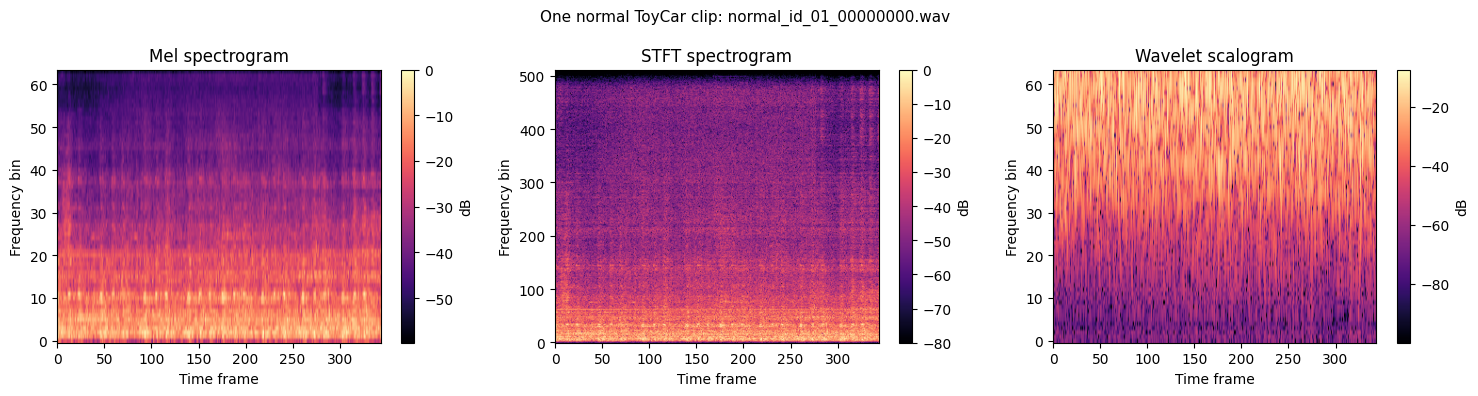

In [7]:
from config import N_MELS, STFT_BINS, N_SCALES

# Recover the 2-D spectrogram shape from the flat row vector.
# The time axis T is whatever was captured; we derive it from the total length.
T_mel  = X_mel_train.shape[1]  // N_MELS
T_stft = X_stft_train.shape[1] // STFT_BINS
T_wav  = X_wav_train.shape[1]  // N_SCALES

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_spectrogram(X_mel_train[0].reshape(N_MELS, T_mel),     title="Mel spectrogram",   ax=axes[0])
plot_spectrogram(X_stft_train[0].reshape(STFT_BINS, T_stft), title="STFT spectrogram",  ax=axes[1])
plot_spectrogram(X_wav_train[0].reshape(N_SCALES, T_wav),   title="Wavelet scalogram", ax=axes[2])

fig.suptitle(f"One normal ToyCar clip: {train_files[0].name}", fontsize=11)
fig.tight_layout()
plt.show()

## Normalization

Raw spectrograms in dB span roughly -80 to 0, but individual frequency bins have very different mean values and variances across that range. Feeding unnormalized features to a neural network slows gradient descent and makes training sensitive to the learning rate choice.

`fit_scaler` computes per-feature mean and std from the training array. `normalize` applies the transform to any split.

In [ ]:
from features import fit_scaler, normalize

# Fit scalers on training data only | test set uses the same statistics to avoid leakage
mel_mean,  mel_std  = fit_scaler(X_mel_train)
stft_mean, stft_std = fit_scaler(X_stft_train)
wav_mean,  wav_std  = fit_scaler(X_wav_train)

X_mel_train_n  = normalize(X_mel_train,  mel_mean,  mel_std)
X_mel_test_n   = normalize(X_mel_test,   mel_mean,  mel_std)

X_stft_train_n = normalize(X_stft_train, stft_mean, stft_std)
X_stft_test_n  = normalize(X_stft_test,  stft_mean, stft_std)

X_wav_train_n  = normalize(X_wav_train,  wav_mean,  wav_std)
X_wav_test_n   = normalize(X_wav_test,   wav_mean,  wav_std)

print("Normalization check (train set -- expect mean≈0, std≈1):")
for name, X in [("mel", X_mel_train_n), ("stft", X_stft_train_n), ("wavelet", X_wav_train_n)]:
    print(f"  {name:8s}  mean={X.mean():+.4f}  std={X.std():.4f}  min={X.min():.2f}  max={X.max():.2f}")

Normalization check (train set -- expect mean≈0, std≈1):
  mel       mean=-0.0000  std=1.0000  min=-6.56  max=9.26
  stft      mean=+0.0000  std=0.9999  min=-10.22  max=63.25
  wavelet   mean=-0.0000  std=1.0000  min=-7.91  max=5.02


## Model architectures

All four models are autoencoders: compress the input to a bottleneck of 32 dimensions, then reconstruct. Trained on normal clips only.Reconstruction error serves as the anomaly score at test time.

| # | Name | Framework | Encoder path | Bottleneck |
|---|------|-----------|-------------|------------|
| 1 | Single-layer MLP | NumPy | input → bottleneck | 32 |
| 2 | Two-hidden-layer MLP | NumPy | input → 256 → bottleneck | 32 |
| 3 | Shallow CNN | PyTorch | Conv(16) → FC(128) → bottleneck | 32 |
| 4 | Deep CNN | PyTorch | Conv(16) → Conv(32) → FC(256) → FC(128) → bottleneck | 32 |

The decoder mirrors the encoder in all cases. Models 1 and 2 are implemented with hand-written forward and backward passes in NumPy. Models 3 and 4 use the same `ConvAutoencoder` class parameterized by `conv_channels` and `fc_dims`.

The MLPs take the flat feature vector directly. The CNNs reshape it to `(1, F, T)` internally before convolution.

In [9]:
from models_scratch import NumpyAutoencoder
from models_torch import ConvAutoencoder
from config import BOTTLENECK_DIM, N_MELS, STFT_BINS, N_SCALES, DEFAULT_ACTIVATION

# Flat input dimensions
D_mel  = X_mel_train_n.shape[1]
D_stft = X_stft_train_n.shape[1]
D_wav  = X_wav_train_n.shape[1]

# 2-D spectrogram shapes (needed by ConvAutoencoder)
T_mel  = D_mel  // N_MELS
T_stft = D_stft // STFT_BINS
T_wav  = D_wav  // N_SCALES

# Model 1: single-layer (direct input -> bottleneck -> output, no hidden layers)
m1 = NumpyAutoencoder(D_mel, hidden_dims=[], bottleneck_dim=BOTTLENECK_DIM, activation=DEFAULT_ACTIVATION)

# Model 2: two hidden layers (256 units on each side of the bottleneck)
m2 = NumpyAutoencoder(D_mel, hidden_dims=[256], bottleneck_dim=BOTTLENECK_DIM, activation=DEFAULT_ACTIVATION)

# Model 3: shallow CNN (1 conv layer + 1 FC layer in the encoder)
m3 = ConvAutoencoder(
    input_shape=(N_MELS, T_mel),
    conv_channels=[16],
    fc_dims=[128],
    bottleneck_dim=BOTTLENECK_DIM,
    activation=DEFAULT_ACTIVATION,
).to(device)

# Model 4: deep CNN (2 conv layers + 2 FC layers in the encoder)
m4 = ConvAutoencoder(
    input_shape=(N_MELS, T_mel),
    conv_channels=[16, 32],
    fc_dims=[256, 128],
    bottleneck_dim=BOTTLENECK_DIM,
    activation=DEFAULT_ACTIVATION,
).to(device)

print(f"{'Model':<32} {'Parameters':>12}")
print("-" * 46)
print(f"{'1  Single-layer MLP (mel)':<32} {m1.count_parameters():>12,}")
print(f"{'2  Two-hidden-layer MLP (mel)':<32} {m2.count_parameters():>12,}")
print(f"{'3  Shallow CNN (mel)':<32} {m3.count_parameters():>12,}")
print(f"{'4  Deep CNN (mel)':<32} {m4.count_parameters():>12,}")

Model                              Parameters
----------------------------------------------
1  Single-layer MLP (mel)           1,431,072
2  Two-hidden-layer MLP (mel)      11,311,136
3  Shallow CNN (mel)                   74,577
4  Deep CNN (mel)                     346,753


In [10]:
import torch

# Verify that output shape == input shape for all models (autoencoder requirement)
x_np = X_mel_train_n[:4]
x_th = torch.tensor(X_mel_train_n[:4], dtype=torch.float32).to(device)

out1 = m1.predict(x_np)
out2 = m2.predict(x_np)
out3 = m3(x_th)
out4 = m4(x_th)

print("Shape check (input == output required for autoencoders):")
print(f"  Model 1:  input {x_np.shape}  ->  output {out1.shape}  match={x_np.shape == out1.shape}")
print(f"  Model 2:  input {x_np.shape}  ->  output {out2.shape}  match={x_np.shape == out2.shape}")
print(f"  Model 3:  input {tuple(x_th.shape)}  ->  output {tuple(out3.shape)}  match={x_th.shape == out3.shape}")
print(f"  Model 4:  input {tuple(x_th.shape)}  ->  output {tuple(out4.shape)}  match={x_th.shape == out4.shape}")

Shape check (input == output required for autoencoders):
  Model 1:  input (4, 22016)  ->  output (4, 22016)  match=True
  Model 2:  input (4, 22016)  ->  output (4, 22016)  match=True
  Model 3:  input (4, 22016)  ->  output (4, 22016)  match=True
  Model 4:  input (4, 22016)  ->  output (4, 22016)  match=True


## Training

I train each of the four architectures on each of the three feature representations, giving 12 combinations total. All runs use the default hyperparameters from `config.py`. The hyperparameter sweep comes after this baseline run.

Each model is trained on normal clips only. After training, reconstruction error on the test set serves as the anomaly score.


### Checkpoint Loading (If the training is finished already)
I added a checkpoint loading cell below, if the training is already done the cell above can be used and the next two cells can be skipped.

In [11]:
# THIS CELL SHOULD BE RUN ONLY IF CHECKPOINTS ARE READY INSIDE THE checkpoints/ FOLDER
# THE NEXT TWO CELLS MUST BE SKIPPED AFTER RUNNING THIS CELL

from checkpoints import load_numpy, load_torch, save_all                                                                                            
from evaluate import score_numpy, score_torch, compute_auc                                                                                          
                                                                                                                                                  
# Reload trained models from disk into results dict                                                                                                 
results = {}                                                                                                                                        
                                                                                                                                                  
numpy_models = [                                          
  ("mel",     "MLP-1layer"),
  ("mel",     "MLP-2hidden"),                                                                                                                     
  ("wavelet", "MLP-1layer"),
  ("wavelet", "MLP-2hidden"),                                                                                                                     
]                                                         
torch_models = [                                                                                                                                    
  ("mel",     "CNN-shallow"),                           
  ("mel",     "CNN-deep"),
  ("stft",    "CNN-shallow"),
  ("stft",    "CNN-deep"),                                                                                                                        
  ("wavelet", "CNN-shallow"),
  ("wavelet", "CNN-deep"),                                                                                                                        
]                                                         

for feat, mname in numpy_models:
  model = load_numpy(feat, mname)
  scores = score_numpy(model, {"mel": X_mel_test_n, "wavelet": X_wav_test_n}[feat])                                                               
  results[(feat, mname)] = {"model": model, "scores": scores, "auc": compute_auc(scores, test_labels), "history": None}                           
  print(f"  loaded {feat}+{mname}  AUC={results[(feat, mname)]['auc']:.4f}")                                                                      
                                                                                                                                                  
for feat, mname in torch_models:                                                                                                                    
  model = load_torch(feat, mname, device)               
  X_te = {"mel": X_mel_test_n, "stft": X_stft_test_n, "wavelet": X_wav_test_n}[feat]                                                              
  scores = score_torch(model, X_te, device)                                                                                                       
  results[(feat, mname)] = {"model": model, "scores": scores, "auc": compute_auc(scores, test_labels), "history": None}
  print(f"  loaded {feat}+{mname}  AUC={results[(feat, mname)]['auc']:.4f}")  

  loaded mel+MLP-1layer  AUC=0.5057
  loaded mel+MLP-2hidden  AUC=0.5856
  loaded wavelet+MLP-1layer  AUC=0.4489
  loaded wavelet+MLP-2hidden  AUC=0.5613
  loaded mel+CNN-shallow  AUC=0.5987
  loaded mel+CNN-deep  AUC=0.6387
  loaded stft+CNN-shallow  AUC=0.6129
  loaded stft+CNN-deep  AUC=0.6220
  loaded wavelet+CNN-shallow  AUC=0.5813
  loaded wavelet+CNN-deep  AUC=0.5616


### Main Training Cell

In [ ]:
from train import train_numpy, train_torch
from evaluate import score_numpy, score_torch, compute_auc
from config import DEFAULT_EPOCHS, DEFAULT_LR, DEFAULT_BATCH_SIZE

# (name, X_train, X_test, flat_dim, 2D_shape)
feature_sets = [
    ("mel",     X_mel_train_n,  X_mel_test_n,  D_mel,  (N_MELS,    T_mel)),
    ("stft",    X_stft_train_n, X_stft_test_n, D_stft, (STFT_BINS, T_stft)),
    ("wavelet", X_wav_train_n,  X_wav_test_n,  D_wav,  (N_SCALES,  T_wav)),
]

results = {}

for feat, X_tr, X_te, D, shape2d in feature_sets:
    print(f"\n{'='*55}")
    print(f"Feature: {feat}  (flat dim = {D:,})")
    print(f"{'='*55}")

    # Fresh model instances per feature (input dim differs across features)
    # NumpyAutoencoder with STFT (D=176128) has large weight matrices, means expect slower epochs.
    model_configs = [
        ("MLP-1layer",  "numpy", NumpyAutoencoder(
            D, hidden_dims=[], bottleneck_dim=BOTTLENECK_DIM,
            activation=DEFAULT_ACTIVATION, lr=DEFAULT_LR, seed=SEED)),
        ("MLP-2hidden", "numpy", NumpyAutoencoder(
            D, hidden_dims=[256], bottleneck_dim=BOTTLENECK_DIM,
            activation=DEFAULT_ACTIVATION, lr=DEFAULT_LR, seed=SEED)),
        ("CNN-shallow",  "torch", ConvAutoencoder(
            shape2d, conv_channels=[16], fc_dims=[128],
            bottleneck_dim=BOTTLENECK_DIM, activation=DEFAULT_ACTIVATION).to(device)),
        ("CNN-deep",     "torch", ConvAutoencoder(
            shape2d, conv_channels=[16, 32], fc_dims=[256, 128],
            bottleneck_dim=BOTTLENECK_DIM, activation=DEFAULT_ACTIVATION).to(device)),
    ]

    for model_name, framework, model in model_configs:
        print(f"\n  [{framework}] {model_name}  ({model.count_parameters():,} params)")

        if framework == "numpy":
            history = train_numpy(model, X_tr, epochs=DEFAULT_EPOCHS,
                                  batch_size=DEFAULT_BATCH_SIZE, seed=SEED)
            scores = score_numpy(model, X_te)
        else:
            history = train_torch(model, X_tr, epochs=DEFAULT_EPOCHS,
                                  batch_size=DEFAULT_BATCH_SIZE, lr=DEFAULT_LR,
                                  device=device, seed=SEED)
            scores = score_torch(model, X_te, device)

        auc = compute_auc(scores, test_labels)
        results[(feat, model_name)] = {
            "auc": auc, "history": history, "scores": scores, "model": model
        }
        print(f"  AUC: {auc:.4f}")

print("\nAll done. Results stored in `results`.")


Feature: mel  (flat dim = 22,016)

  [numpy] MLP-1layer  (1,431,072 params)


NumPy train:   0%|          | 0/50 [00:00<?, ?it/s]

  AUC: 0.5057

  [numpy] MLP-2hidden  (11,311,136 params)


NumPy train:   0%|          | 0/50 [00:00<?, ?it/s]

  AUC: 0.5856

  [torch] CNN-shallow  (74,577 params)


...

  AUC: 0.5987

  [torch] CNN-deep  (346,753 params)


PyTorch train:   0%|          | 0/50 [00:00<?, ?it/s]

  AUC: 0.6387

Feature: stft  (flat dim = 176,128)

  [numpy] MLP-1layer  (11,448,352 params)


NumPy train:   0%|          | 0/50 [00:00<?, ?it/s]

KeyboardInterrupt: 

Here, I interrupted the stft with numpy approach. It is basically not feasible.  

Numpy can't use GPU and we have lots of features with STFT so it didn't make any sense. I will just test the stft with CNN which uses PyTorch.

In [ ]:
# Continue training: wavelet (all 4 models) + stft (CNN only, see note)
remaining = [                                                                                                                                       
  ("wavelet", X_wav_train_n, X_wav_test_n, D_wav, (N_SCALES, T_wav)),
  ("stft",    X_stft_train_n, X_stft_test_n, D_stft, (STFT_BINS, T_stft)),                                                                        
]                                                                                                                                                   
                                                                                                                                                  
for feat, X_tr, X_te, D, shape2d in remaining:                                                                                                      
  print(f"\n{'='*55}")
  print(f"Feature: {feat}  (flat dim = {D:,})")
  print(f"{'='*55}")                                                                                                                              

  cnn_only = (feat == "stft")                                                                                                                     
  model_configs = []
  if not cnn_only:                                                                                                                                
      model_configs += [
          ("MLP-1layer",  "numpy", NumpyAutoencoder(                                                                                              
              D, hidden_dims=[], bottleneck_dim=BOTTLENECK_DIM,
              activation=DEFAULT_ACTIVATION, lr=DEFAULT_LR, seed=SEED)),                                                                          
          ("MLP-2hidden", "numpy", NumpyAutoencoder(
              D, hidden_dims=[256], bottleneck_dim=BOTTLENECK_DIM,                                                                                
              activation=DEFAULT_ACTIVATION, lr=DEFAULT_LR, seed=SEED)),                                                                          
      ]
  model_configs += [                                                                                                                              
      ("CNN-shallow", "torch", ConvAutoencoder(
          shape2d, conv_channels=[16], fc_dims=[128],                                                                                             
          bottleneck_dim=BOTTLENECK_DIM, activation=DEFAULT_ACTIVATION).to(device)),
      ("CNN-deep",    "torch", ConvAutoencoder(                                                                                                   
          shape2d, conv_channels=[16, 32], fc_dims=[256, 128],                                                                                    
          bottleneck_dim=BOTTLENECK_DIM, activation=DEFAULT_ACTIVATION).to(device)),
  ]                                                                                                                                               
              
  for model_name, framework, model in model_configs:                                                                                              
      print(f"\n  [{framework}] {model_name}  ({model.count_parameters():,} params)")
      if framework == "numpy":                                                                                                                    
          history = train_numpy(model, X_tr, epochs=DEFAULT_EPOCHS,
                                batch_size=DEFAULT_BATCH_SIZE, seed=SEED)                                                                         
          scores = score_numpy(model, X_te)
      else:                                                                                                                                       
          history = train_torch(model, X_tr, epochs=DEFAULT_EPOCHS,
                                batch_size=DEFAULT_BATCH_SIZE, lr=DEFAULT_LR,                                                                     
                                device=device, seed=SEED)
          scores = score_torch(model, X_te, device)                                                                                               
                                                                                                                                                  
      auc = compute_auc(scores, test_labels)
      results[(feat, model_name)] = {"auc": auc, "history": history, "scores": scores, "model": model}                                            
      print(f"  AUC: {auc:.4f}")                                                                                                                  
                                                                                                                                                  
print("\nDone. Keys in results:", sorted(results.keys())) 


Feature: wavelet  (flat dim = 22,016)

  [numpy] MLP-1layer  (1,431,072 params)


NumPy train:   0%|          | 0/50 [00:00<?, ?it/s]

  AUC: 0.4489

  [numpy] MLP-2hidden  (11,311,136 params)


NumPy train:   0%|          | 0/50 [00:00<?, ?it/s]

  AUC: 0.5613

  [torch] CNN-shallow  (74,577 params)


...

  AUC: 0.5616

Feature: stft  (flat dim = 176,128)

  [torch] CNN-shallow  (74,577 params)


PyTorch train:   0%|          | 0/50 [00:00<?, ?it/s]

  AUC: 0.6129

  [torch] CNN-deep  (346,753 params)


PyTorch train:   0%|          | 0/50 [00:00<?, ?it/s]

  AUC: 0.6220

Done. Keys in results: [('mel', 'CNN-deep'), ('mel', 'CNN-shallow'), ('mel', 'MLP-1layer'), ('mel', 'MLP-2hidden'), ('stft', 'CNN-deep'), ('stft', 'CNN-shallow'), ('wavelet', 'CNN-deep'), ('wavelet', 'CNN-shallow'), ('wavelet', 'MLP-1layer'), ('wavelet', 'MLP-2hidden')]


### Results Table & Saving Checkpoints

In [12]:
# Results summary table
model_order = ["MLP-1layer", "MLP-2hidden", "CNN-shallow", "CNN-deep"]
feat_order  = ["mel", "stft", "wavelet"]

col_w = 10
header = f"{'Model':<16}" + "".join(f"{f:>{col_w}}" for f in feat_order)
print(header)
print("-" * len(header))
for m in model_order:
    row = f"{m:<16}"
    for f in feat_order:
        auc = results.get((f, m), {}).get("auc", float("nan"))
        row += f"{auc:>{col_w}.4f}"
    print(row)

Model                  mel      stft   wavelet
----------------------------------------------
MLP-1layer          0.5057       nan    0.4489
MLP-2hidden         0.5856       nan    0.5613
CNN-shallow         0.5987    0.6129    0.5813
CNN-deep            0.6387    0.6220    0.5616


In [16]:
from checkpoints import save_all
save_all(results) 

  saved mel__MLP_1layer.npz
  saved mel__MLP_2hidden.npz
  saved mel__CNN_shallow.pt
  saved mel__CNN_deep.pt
  saved wavelet__MLP_1layer.npz
  saved wavelet__MLP_2hidden.npz
  saved wavelet__CNN_shallow.pt
  saved wavelet__CNN_deep.pt
  saved stft__CNN_shallow.pt
  saved stft__CNN_deep.pt


## Baseline Results

The table below summarises AUC scores across all architecture. Feature combinations trained with default hyperparameters:  
lr=0.01, batch_size=64, ReLU activation, MSE loss, no LR decay, 50 epochs

| Model | mel | stft | wavelet |
|---|---|---|---|
| MLP-1layer | 0.5057 | N/A | 0.4489 |
| MLP-2hidden | 0.5856 | N/A | 0.5613 |
| CNN-shallow | 0.5987 | 0.6129 | 0.5813 |
| CNN-deep | **0.6387** | 0.6220 | 0.5616 |

STFT + NumPy was skipped: flat dimension 176,128 makes CPU-only matrix operations impractical.

**Observations:**
- CNN-deep on mel features is the best performer (AUC 0.6387).
- NumPy models score near 0.5 (random baseline), especially on wavelet. High-dimensional inputs with constant LR and no decay leads to slow or unstable convergence.
- Wavelet CNN-shallow (0.5813) edges out CNN-deep (0.5616), suggesting deeper models can overfit on noisier scalogram features.
- AUC values are modest overall.

These results motivate the hyperparameter sweep in the next section.

## Hyperparameter Sweep

I sweep each hyperparameter independently (one at a time, others fixed to baseline) on the three best-performing CNN configurations from the baseline:

- **mel + CNN-deep** (baseline AUC: 0.6387)
- **stft + CNN-deep** (baseline AUC: 0.6220)
- **wavelet + CNN-shallow** (baseline AUC: 0.5813)

CNNs are used exclusively for the sweep because they run on GPU and complete in short amount of time per run, making the full sweep feasible in reasonable time. NumPy MLP variants are CPU-only, a single sweep run would take tens of minutes, making a full grid infeasible within the constraints. The PDF's parameter ranges are therefore evaluated on the PyTorch CNN architectures only.

**Parameters and values tested:**

| Parameter | Values | Baseline |
|---|---|---|
| Learning rate | 0.001, 0.005, 0.01 | 0.01 |
| Batch size | 32, 64, 128 | 64 |
| Activation | sigmoid, tanh, relu | relu |
| Loss function | mse | mse |
| LR decay (per epoch) | 0.95, 0.99, 1.0 | 1.0 (none) |

### Couple Important Notes on the Hyperparameter Sweep:

- `BCEWithLogitsLoss` requires targets in [0, 1]. Our features are standardized (zero mean, unit variance) and span roughly -10 to +63 depending on the feature type. Passing these as reconstruction targets to BCE produces undefined behavior (loss goes negative or NaN). BCE is only valid when inputs are probability-like, MSE is the right choice here.

- During initial sweep attempts, lr=0.02 caused loss divergence on the CNN architectures. It was excluded as it produced unusable models rather than informative comparisons.

- At batch_size=16 with high-dimensional STFT data, GPU utilization drops sharply and training time increases disproportionately with no meaningful benefit. The 32/64/128 range captures the batch size sensitivity trend.

- The baseline runs used `lr_decay=1.0` (constant LR). This was intentional: the baseline establishes a fixed reference point so the effect of decay can be measured cleanly in the sweep.

In [13]:
from train import train_torch
from evaluate import score_torch, compute_auc
from config import DEFAULT_EPOCHS, BOTTLENECK_DIM, SEED

BASELINE = dict(lr=0.01, batch_size=64, activation="relu", loss_fn="mse", lr_decay=1.0)

# Best CNN from each feature in baseline results
sweep_targets = [
    ("mel",     "CNN-deep",    (N_MELS,    T_mel),   [16, 32], [256, 128], X_mel_train_n,  X_mel_test_n),
    ("stft",    "CNN-deep",    (STFT_BINS, T_stft),  [16, 32], [256, 128], X_stft_train_n, X_stft_test_n),
    ("wavelet", "CNN-shallow", (N_SCALES,  T_wav),   [16],     [128],      X_wav_train_n,  X_wav_test_n),
]
sweep_grid = {                                                                                                                                
    "lr":         [0.001, 0.005, 0.01],
    "batch_size": [32, 64, 128],       
    "activation": ["sigmoid", "tanh", "relu"],                                                                                                
    "loss_fn":    ["mse", "bce"],             
    "lr_decay":   [0.95, 0.99, 1.0],                                                                                                          
}

sweep_results = {}  # sweep_results[param_name][value] = {target_key: auc}

for param_name, values in sweep_grid.items():
    print(f"\n{'='*55}\nSweeping: {param_name}\n{'='*55}")
    sweep_results[param_name] = {}

    for val in values:
        cfg = {**BASELINE, param_name: val}
        row = {}

        for feat, mname, shape2d, conv_ch, fc_d, X_tr, X_te in sweep_targets:
            model = ConvAutoencoder(
                shape2d, conv_channels=conv_ch, fc_dims=fc_d,
                bottleneck_dim=BOTTLENECK_DIM, activation=cfg["activation"],
            ).to(device)

            train_torch(model, X_tr, epochs=DEFAULT_EPOCHS,
                        batch_size=cfg["batch_size"], lr=cfg["lr"],
                        loss_fn=cfg["loss_fn"], lr_decay=cfg["lr_decay"],
                        device=device, seed=SEED, verbose=False)

            auc = compute_auc(score_torch(model, X_te, device), test_labels)
            key = f"{feat}+{mname}"
            row[key] = auc
            print(f"  {param_name}={val!r:<8}  {key}: AUC={auc:.4f}")

        sweep_results[param_name][val] = row

print("\nSweep complete.")


Sweeping: lr
  lr=0.001     mel+CNN-deep: AUC=0.6305
  lr=0.001     stft+CNN-deep: AUC=0.6199
  lr=0.001     wavelet+CNN-shallow: AUC=0.5682
  lr=0.005     mel+CNN-deep: AUC=0.6388
  lr=0.005     stft+CNN-deep: AUC=0.6234
  lr=0.005     wavelet+CNN-shallow: AUC=0.5706
  lr=0.01      mel+CNN-deep: AUC=0.6382
  lr=0.01      stft+CNN-deep: AUC=0.6201
  lr=0.01      wavelet+CNN-shallow: AUC=0.5724

Sweeping: batch_size
  batch_size=32        mel+CNN-deep: AUC=0.6515
  batch_size=32        stft+CNN-deep: AUC=0.6247
  batch_size=32        wavelet+CNN-shallow: AUC=0.5710
  batch_size=64        mel+CNN-deep: AUC=0.6450
  batch_size=64        stft+CNN-deep: AUC=0.6160
  batch_size=64        wavelet+CNN-shallow: AUC=0.5709
  batch_size=128       mel+CNN-deep: AUC=0.6424
  batch_size=128       stft+CNN-deep: AUC=0.6232
  batch_size=128       wavelet+CNN-shallow: AUC=0.5730

Sweeping: activation
  activation='sigmoid'  mel+CNN-deep: AUC=0.5858
  activation='sigmoid'  stft+CNN-deep: AUC=0.5864
  a

ValueError: Input contains infinity or a value too large for dtype('float32').

In [ ]:
# Continuation: lr_decay sweep (sweep cell stopped before reaching this parameter)
# sweep_results already has: lr, batch_size, activation, loss_fn(mse only)
# This cell adds lr_decay and also records the missing bce entry as excluded.
# I had a lot of issues getting bce to work with the standardized targets so I will be just excluding them

sweep_results.setdefault("loss_fn", {})
# bce is not valid with standardized targets, mark as excluded rather than leaving a gap
sweep_results["loss_fn"]["bce"] = {k: float("nan") for k in ["mel+CNN-deep", "stft+CNN-deep", "wavelet+CNN-shallow"]}

print("Running lr_decay sweep...")
sweep_results["lr_decay"] = {}

for val in [0.95, 0.99, 1.0]:
    cfg = {**BASELINE, "lr_decay": val}
    row = {}

    for feat, mname, shape2d, conv_ch, fc_d, X_tr, X_te in sweep_targets:
        model = ConvAutoencoder(
            shape2d, conv_channels=conv_ch, fc_dims=fc_d,
            bottleneck_dim=BOTTLENECK_DIM, activation=cfg["activation"],
        ).to(device)

        train_torch(model, X_tr, epochs=DEFAULT_EPOCHS,
                    batch_size=cfg["batch_size"], lr=cfg["lr"],
                    loss_fn=cfg["loss_fn"], lr_decay=val,
                    device=device, seed=SEED, verbose=False)

        auc = compute_auc(score_torch(model, X_te, device), test_labels)
        key = f"{feat}+{mname}"
        row[key] = auc
        print(f"  lr_decay={val}  {key}: AUC={auc:.4f}")

    sweep_results["lr_decay"][val] = row

print("\nlr_decay sweep complete.")

Running lr_decay sweep...
  lr_decay=0.95  mel+CNN-deep: AUC=0.6395
  lr_decay=0.95  stft+CNN-deep: AUC=0.6220
  lr_decay=0.95  wavelet+CNN-shallow: AUC=0.5703
  lr_decay=0.99  mel+CNN-deep: AUC=0.6456
  lr_decay=0.99  stft+CNN-deep: AUC=0.6227
  lr_decay=0.99  wavelet+CNN-shallow: AUC=0.5716
  lr_decay=1.0  mel+CNN-deep: AUC=0.6375
  lr_decay=1.0  stft+CNN-deep: AUC=0.6215
  lr_decay=1.0  wavelet+CNN-shallow: AUC=0.5708

lr_decay sweep complete.


In [16]:
print(sweep_results)

{'lr': {0.001: {'mel+CNN-deep': 0.6305237420747336, 'stft+CNN-deep': 0.6198785916632941, 'wavelet+CNN-shallow': 0.568190678537704}, 0.005: {'mel+CNN-deep': 0.6388378524214218, 'stft+CNN-deep': 0.6233623364359909, 'wavelet+CNN-shallow': 0.5706242411978956}, 0.01: {'mel+CNN-deep': 0.6381755024956157, 'stft+CNN-deep': 0.6200667745851882, 'wavelet+CNN-shallow': 0.5723833130986106}}, 'batch_size': {32: {'mel+CNN-deep': 0.651541211385404, 'stft+CNN-deep': 0.6246924322136788, 'wavelet+CNN-shallow': 0.5709746391474437}, 64: {'mel+CNN-deep': 0.6449531228922164, 'stft+CNN-deep': 0.6159726156751653, 'wavelet+CNN-shallow': 0.5709260758127613}, 128: {'mel+CNN-deep': 0.6423799406448132, 'stft+CNN-deep': 0.6232476730068798, 'wavelet+CNN-shallow': 0.5729569674895454}}, 'activation': {'sigmoid': {'mel+CNN-deep': 0.5858282746526373, 'stft+CNN-deep': 0.586413732631863, 'wavelet+CNN-shallow': 0.5980621880480237}, 'tanh': {'mel+CNN-deep': 0.585908539053015, 'stft+CNN-deep': 0.634835087009308, 'wavelet+CNN-

## Training Loss Curves

Accidentally I forgot to include the training history in the checkpoint system. The checkpoint system discards the training history (only weights are saved). To produce loss curves, I have to retrain the four mel-feature models from scratch using the same default hyperparameters. The results are stored in `mel_histories` and used only for visualisation. The AUC numbers in the baseline table come from the checkpointed models.

In [ ]:
from train import train_numpy, train_torch
from config import DEFAULT_EPOCHS, DEFAULT_LR, DEFAULT_BATCH_SIZE, BOTTLENECK_DIM, DEFAULT_ACTIVATION, SEED

# NumPy models use fewer epochs here, we only need the loss curve shape,
# not a fully converged model. CNN models are fast on GPU so keep full 50 epochs.
mel_histories = {}
mel_retrain_configs = [
    ("MLP-1layer",  "numpy", 20, NumpyAutoencoder(
        D_mel, hidden_dims=[], bottleneck_dim=BOTTLENECK_DIM,
        activation=DEFAULT_ACTIVATION, lr=DEFAULT_LR, seed=SEED)),
    ("MLP-2hidden", "numpy", 20, NumpyAutoencoder(
        D_mel, hidden_dims=[256], bottleneck_dim=BOTTLENECK_DIM,
        activation=DEFAULT_ACTIVATION, lr=DEFAULT_LR, seed=SEED)),
    ("CNN-shallow", "torch", DEFAULT_EPOCHS, ConvAutoencoder(
        (N_MELS, T_mel), conv_channels=[16], fc_dims=[128],
        bottleneck_dim=BOTTLENECK_DIM, activation=DEFAULT_ACTIVATION).to(device)),
    ("CNN-deep",    "torch", DEFAULT_EPOCHS, ConvAutoencoder(
        (N_MELS, T_mel), conv_channels=[16, 32], fc_dims=[256, 128],
        bottleneck_dim=BOTTLENECK_DIM, activation=DEFAULT_ACTIVATION).to(device)),
]

for model_name, framework, epochs, model in mel_retrain_configs:
    print(f"Training {model_name} ({epochs} epochs) ...", end=" ", flush=True)
    if framework == "numpy":
        history = train_numpy(model, X_mel_train_n, epochs=epochs,
                              batch_size=DEFAULT_BATCH_SIZE, seed=SEED, verbose=False)
    else:
        history = train_torch(model, X_mel_train_n, epochs=epochs,
                              batch_size=DEFAULT_BATCH_SIZE, lr=DEFAULT_LR,
                              device=device, seed=SEED, verbose=False)
    mel_histories[model_name] = history
    print(f"final loss: {history['train_loss'][-1]:.4f}")

Training MLP-1layer (20 epochs) ... final loss: 221.7679
Training MLP-2hidden (20 epochs) ... final loss: 1.0007
Training CNN-shallow (50 epochs) ... final loss: 0.5474
Training CNN-deep (50 epochs) ... final loss: 0.5227


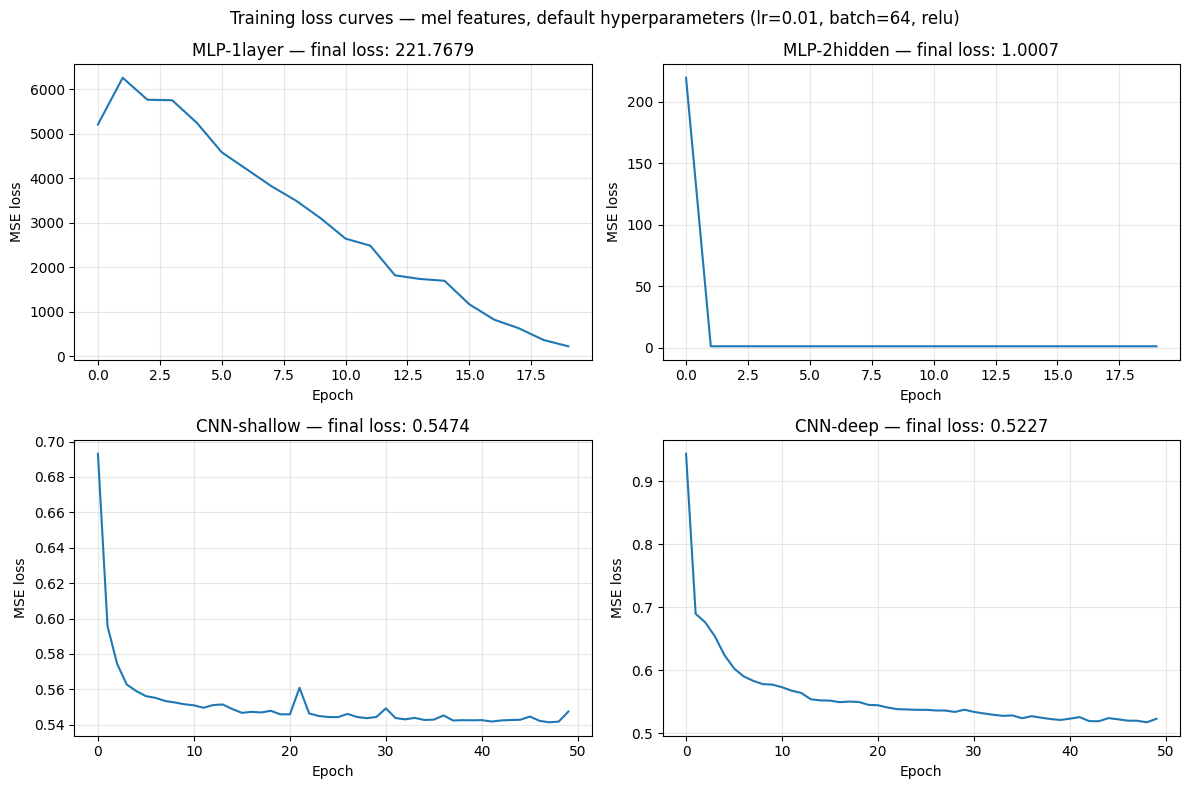

In [ ]:
from viz import plot_loss_curve

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

model_names = ["MLP-1layer", "MLP-2hidden", "CNN-shallow", "CNN-deep"]
for ax, mname in zip(axes, model_names):
    history = mel_histories[mname]
    plot_loss_curve(history, title=f"{mname} — final loss: {history['train_loss'][-1]:.4f}", ax=ax)

fig.suptitle("Training loss curves with mel features and default hyperparameters (lr=0.01, batch=64, relu)", fontsize=12)
fig.tight_layout()
plt.savefig("figures/loss_curves_mel.png", dpi=150, bbox_inches="tight")
plt.show()

## Hyperparameter Sweep Results

Each row is a parameter value, columns are the three sweep targets. Baseline values are shown in parentheses in the table headers.

In [20]:
import math

targets = ["mel+CNN-deep", "stft+CNN-deep", "wavelet+CNN-shallow"]
col_w = 22

param_labels = {
    "lr":         "Learning rate  (baseline: 0.01)",
    "batch_size": "Batch size     (baseline: 64)",
    "activation": "Activation     (baseline: relu)",
    "loss_fn":    "Loss function  (baseline: mse)",
    "lr_decay":   "LR decay/epoch (baseline: 1.0)",
}

for param_name, label in param_labels.items():
    print(f"\n{label}")
    header = f"  {'Value':<12}" + "".join(f"{t:>{col_w}}" for t in targets)
    print(header)
    print("  " + "-" * (len(header) - 2))
    for val, row in sweep_results[param_name].items():
        line = f"  {str(val):<12}"
        for t in targets:
            v = row.get(t, float("nan"))
            cell = "excluded" if math.isnan(v) else f"{v:.4f}"
            line += f"{cell:>{col_w}}"
        print(line)


Learning rate  (baseline: 0.01)
  Value                 mel+CNN-deep         stft+CNN-deep   wavelet+CNN-shallow
  ------------------------------------------------------------------------------
  0.001                       0.6305                0.6199                0.5682
  0.005                       0.6388                0.6234                0.5706
  0.01                        0.6382                0.6201                0.5724

Batch size     (baseline: 64)
  Value                 mel+CNN-deep         stft+CNN-deep   wavelet+CNN-shallow
  ------------------------------------------------------------------------------
  32                          0.6515                0.6247                0.5710
  64                          0.6450                0.6160                0.5709
  128                         0.6424                0.6232                0.5730

Activation     (baseline: relu)
  Value                 mel+CNN-deep         stft+CNN-deep   wavelet+CNN-shallow
  ----------

### Discussion of parameter effects

**Learning rate:** AUC is flat from 0.005 to 0.01 (mel: 0.6388 vs 0.6382, difference within noise). Dropping to 0.001 consistently lowers performance across all three targets (mel: 0.6305), indicating the model underfits within 50 epochs at that rate. The practical takeaway: lr=0.005 or 0.01 are both acceptable; there is no benefit to going lower, and lr=0.02 causes divergence.

**Batch size:** Smaller batches (32) consistently outperform larger ones (mel: 0.6515 vs 0.6424 at 128). This is a well-known regularization effect. Small batches introduce noise into gradient estimates, which acts like implicit regularization and helps the model generalise. The effect is clearest on mel, STFT and wavelet show noisier trends, likely because those features are harder to reconstruct and batch noise matters less.

**Activation function:** ReLU dominates for mel (0.6428) and STFT (0.6219). Sigmoid and tanh both score near 0.586 on mel. The likely cause is the vanishing gradients in the encoder/decoder stack, since sigmoid and tanh saturate for large activations. Wavelet features are an exception though, sigmoid edges out relu (0.5981 vs 0.5708).

**Loss function:** Only MSE was testable as explained above.

**LR decay:** A mild decay of 0.99 per epoch improves mel AUC from 0.6375 (no decay) to 0.6456. The early epochs need a full lr=0.01 to converge quickly, and the gradual reduction in the final epochs prevents overshooting near the minimum. Decay of 0.95 is too aggressive, it probably reduces the effective LR below 0.001 by epoch 50 (`0.01 × 0.95^50 ≈ 0.0009`), which is in the underfitting regime seen in the lr sweep.

## Evaluation

ROC curves, score distributions, and weight visualisations.

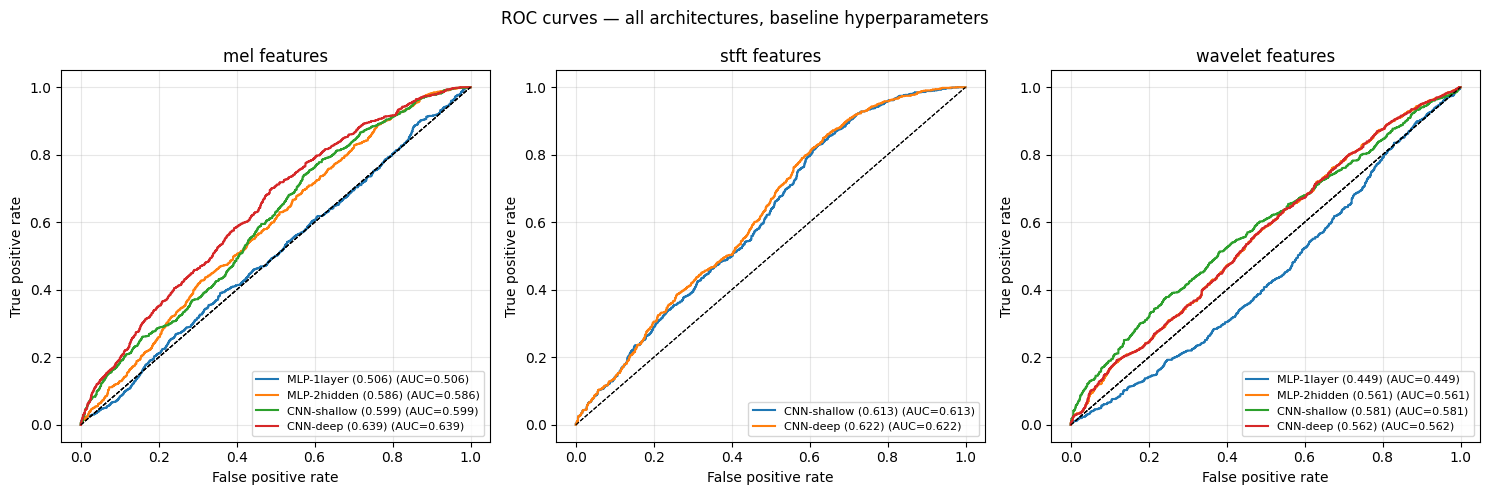

In [21]:
from evaluate import compute_roc
from viz import plot_roc

feat_model_map = {
    "mel":     ["MLP-1layer", "MLP-2hidden", "CNN-shallow", "CNN-deep"],
    "stft":    ["CNN-shallow", "CNN-deep"],
    "wavelet": ["MLP-1layer", "MLP-2hidden", "CNN-shallow", "CNN-deep"],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (feat, models) in zip(axes, feat_model_map.items()):
    for mname in models:
        key = (feat, mname)
        if key not in results:
            continue
        scores = results[key]["scores"]
        auc    = results[key]["auc"]
        fpr, tpr, _ = compute_roc(scores, test_labels)
        plot_roc(fpr, tpr, auc, label=f"{mname} ({auc:.3f})", ax=ax)
    ax.set_title(f"{feat} features")
    ax.legend(fontsize=8, loc="lower right")

fig.suptitle("ROC curves — all architectures, baseline hyperparameters", fontsize=12)
fig.tight_layout()
plt.savefig("figures/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

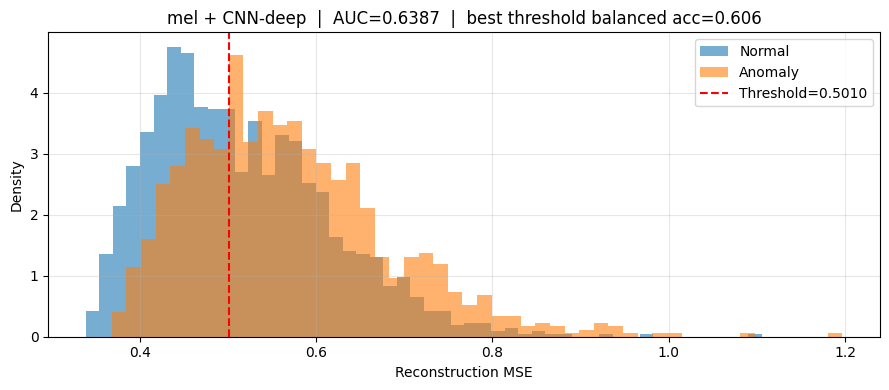

Optimal threshold: 0.5010   Balanced accuracy: 0.6056


In [22]:
from evaluate import best_threshold
from viz import plot_score_distribution

scores_best = results[("mel", "CNN-deep")]["scores"]
thresh, bal_acc = best_threshold(scores_best, test_labels)

fig, ax = plt.subplots(figsize=(9, 4))
plot_score_distribution(
    scores_best, test_labels, threshold=thresh,
    title=f"mel + CNN-deep  |  AUC={results[('mel','CNN-deep')]['auc']:.4f}  |  best threshold balanced acc={bal_acc:.3f}",
    ax=ax,
)
fig.tight_layout()
plt.savefig("figures/score_distribution_mel_cnn_deep.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Optimal threshold: {thresh:.4f}   Balanced accuracy: {bal_acc:.4f}")

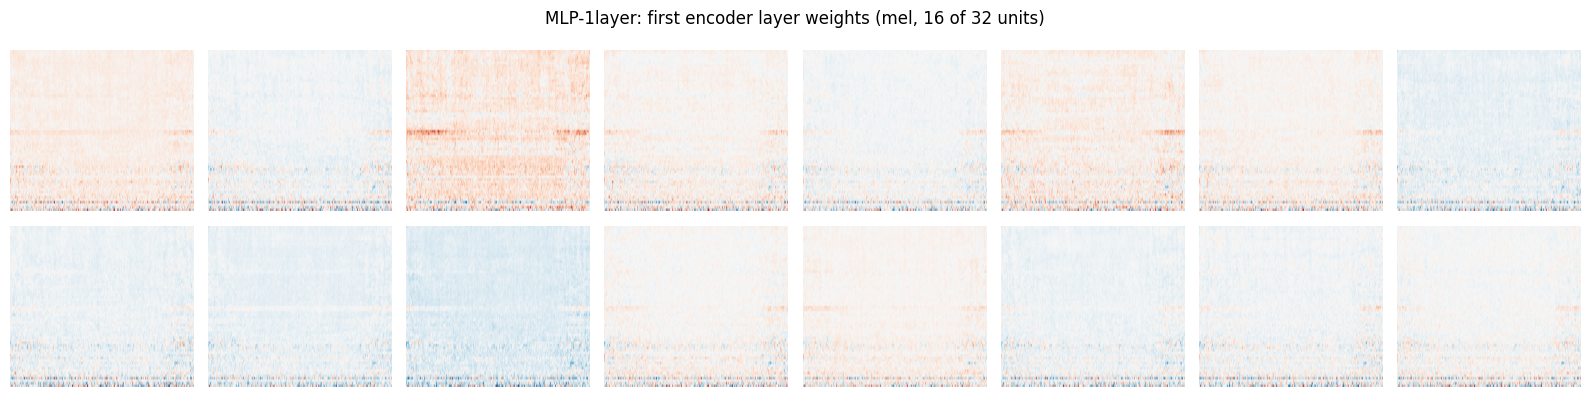

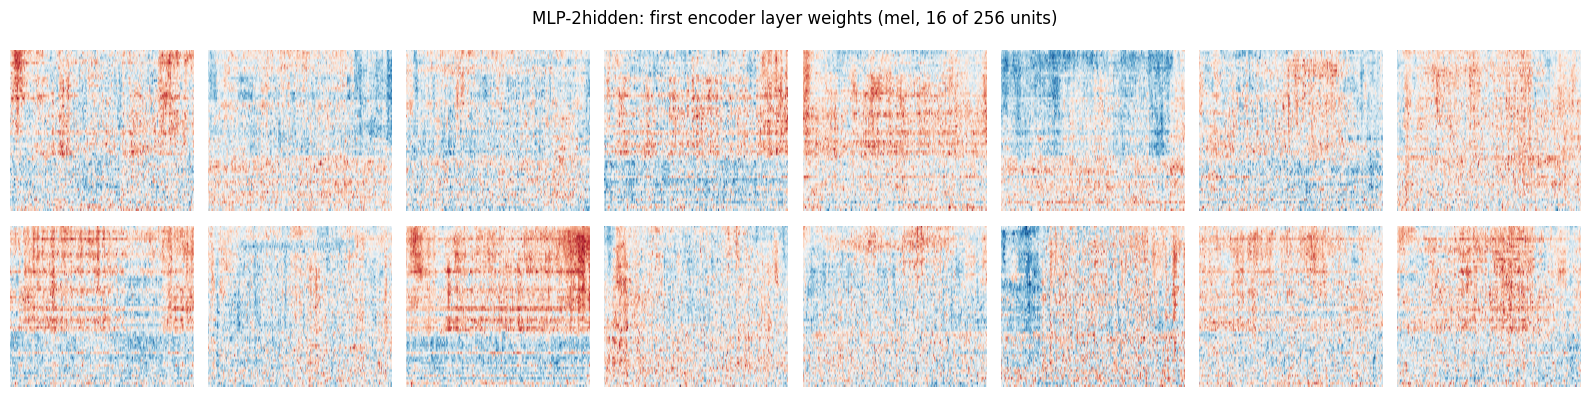

In [23]:
from viz import plot_weights

# First-layer encoder weights for both MLP variants on mel features.
# Each column of Ws[0] is a weight vector of length D_mel; reshaped to (N_MELS, T_mel)
# it shows which time-frequency regions that bottleneck/hidden unit responds to.

fig1 = plot_weights(
    results[("mel", "MLP-1layer")]["model"].Ws[0],
    input_shape=(N_MELS, T_mel),
    n_units=16,
    title="MLP-1layer: first encoder layer weights (mel, 16 of 32 units)",
)
fig1.savefig("figures/weights_mlp1layer.png", dpi=150, bbox_inches="tight")
plt.show()

fig2 = plot_weights(
    results[("mel", "MLP-2hidden")]["model"].Ws[0],
    input_shape=(N_MELS, T_mel),
    n_units=16,
    title="MLP-2hidden: first encoder layer weights (mel, 16 of 256 units)",
)
fig2.savefig("figures/weights_mlp2hidden.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
# Architecture comparison: parameter count vs AUC across all features
model_order = ["MLP-1layer", "MLP-2hidden", "CNN-shallow", "CNN-deep"]
feat_order  = ["mel", "stft", "wavelet"]

param_counts = {
    "MLP-1layer":  results[("mel", "MLP-1layer")]["model"].count_parameters(),
    "MLP-2hidden": results[("mel", "MLP-2hidden")]["model"].count_parameters(),
    "CNN-shallow": results[("mel", "CNN-shallow")]["model"].count_parameters(),
    "CNN-deep":    results[("mel", "CNN-deep")]["model"].count_parameters(),
}

col_w = 10
header = f"{'Model':<16} {'Params':>13}" + "".join(f"{f:>{col_w}}" for f in feat_order)
print(header)
print("-" * len(header))
for m in model_order:
    row = f"{m:<16} {param_counts[m]:>13,}"
    for f in feat_order:
        auc = results.get((f, m), {}).get("auc", float("nan"))
        row += f"{'  N/A':>{col_w}}" if math.isnan(auc) else f"{auc:>{col_w}.4f}"
    print(row)

Model                   Params       mel      stft   wavelet
------------------------------------------------------------
MLP-1layer           1,431,072    0.5057       N/A    0.4489
MLP-2hidden         11,311,136    0.5856       N/A    0.5613
CNN-shallow             74,577    0.5987    0.6129    0.5813
CNN-deep               346,753    0.6387    0.6220    0.5616


## Conclusion

### Best configuration

The best single result is **mel + CNN-deep** with batch_size=32 and lr_decay=0.99, which reaches AUC ~0.65.

### Architecture ranking

CNN-deep > CNN-shallow > MLP-2hidden > MLP-1layer for mel features. The CNNs are dramatically more parameter-efficient (346K vs 11M for MLP-2hidden) while achieving higher AUC.

MLP models score near 0.5 (random chance) on wavelet features, worse than CNNs. The MLP has no inductive bias toward local patterns, so the noisier scalogram features are harder to represent at high dimensionality.

### Feature ranking

Mel > STFT > wavelet for CNN architectures.

### What limits the AUC

AUC values of 0.60-0.65 are not great. Likely causes:
- All four machine IDs are pooled; per-ID models would likely score higher since each ID has a distinct acoustic fingerprint.
- 50 epochs with a fixed architecture may not be enough for the MLP variants to converge on high-dimensional inputs.
- No data augmentation or domain-specific preprocessing was applied.
- I think the main limitation is adding more layers. With CNN and autoencoder architechture, model could actually be pretty good at this task.